# 99b · Final paper figures (revised narrative)

Rebuilds the key headline figures around the **F19 (network) + F20 (landmark null)** narrative. Supersedes notebook 99 for the revised story.

- **Figure 1.** STROBE flow (patient selection).
- **Figure 2.** Trajectory panel (matched cohort LMM + full-cohort landmark means).
- **Figure 3.** Landmark Δ & P(≥2) — F20 null result front-and-centre.
- **Figure 4.** Non-motor symptom network, pain highlighted (F9).
- **Figure 5.** Longitudinal GLASSO — pain-SCOPA coupling over time by arm (F19).
- **Figure 6.** Mediation decomposition (F3).
- **Figure 7.** Positive control — UPDRS-III motor landmark (data-quality proof).
- **Figure 8.** Summary forest of main effects.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(patchwork); library(forcats); library(scales); library(qgraph)
})
theme_pub <- function(base_size = 11) {
  theme_classic(base_size = base_size, base_family = "Helvetica") +
    theme(
      plot.title    = element_text(face = "bold", size = rel(1.05), hjust = 0),
      plot.subtitle = element_text(size = rel(0.9), colour = "grey30", hjust = 0),
      axis.text     = element_text(colour = "grey20"),
      legend.position = "top",
      strip.background = element_blank(),
      strip.text = element_text(face = "bold", size = rel(0.95)),
      panel.grid.major.y = element_line(colour = "grey90", linewidth = 0.25)
    )
}
ARM_PAL  <- c(`DBS` = "#CC6677", `Never-DBS` = "#332288")
TRAJ_PAL <- c(`Pre-DBS` = "#117733", `Post-DBS` = "#CC6677", `Never-DBS` = "#332288")
save_pub <- function(p, name, w = 7.2, h = 5) {
  ggplot2::ggsave(file.path(OUT_FIG, paste0(name, ".png")), p, width = w, height = h, dpi = 300)
  ggplot2::ggsave(file.path(OUT_FIG, paste0(name, ".tiff")), p, width = w, height = h, dpi = 300, compression = "lzw")
  invisible(p)
}

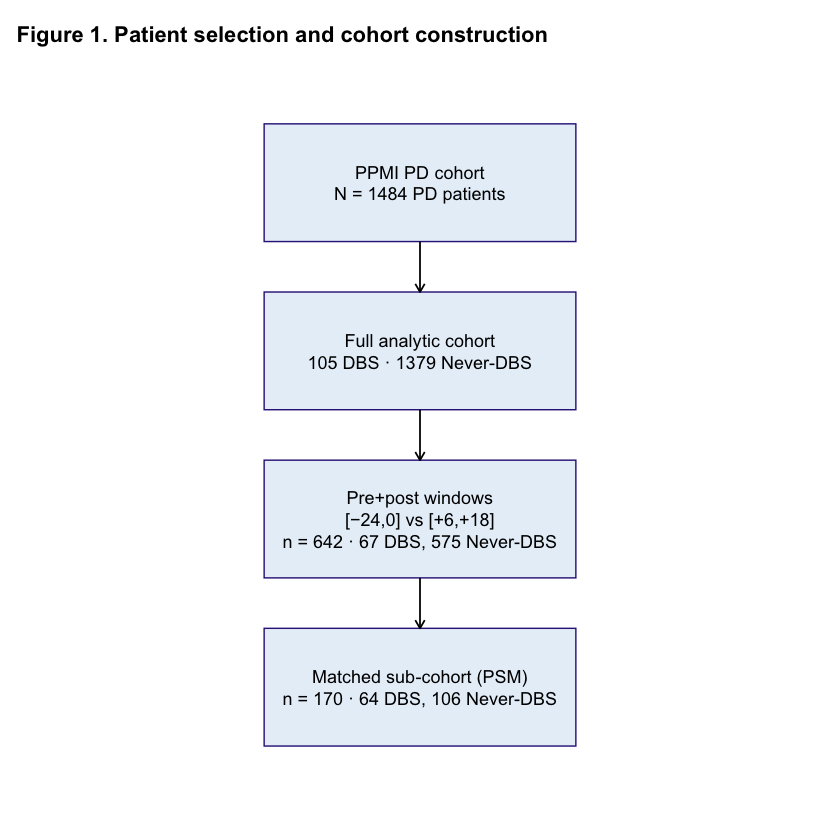

In [2]:
# ---- Figure 1 — STROBE-style flow diagram ----
# Counts pulled from cohort validation
rel <- load_full_ppmi_rel_patient_anchor()
n_full <- dplyr::n_distinct(rel$PATNO)
arm_n <- rel %>% dplyr::distinct(PATNO, will_receive_dbs) %>% dplyr::count(will_receive_dbs)
n_dbs <- arm_n$n[arm_n$will_receive_dbs]; n_nd <- arm_n$n[!arm_n$will_receive_dbs]

feat <- build_per_patient_features(rel, var="NP1PAIN", pre_win=c(-24,0), post_win=c(6,18))
n_windowed <- nrow(feat)
feat_d <- feat %>% dplyr::inner_join(rel %>% dplyr::distinct(PATNO, will_receive_dbs), by="PATNO") %>%
  dplyr::count(will_receive_dbs)
n_wdbs <- feat_d$n[feat_d$will_receive_dbs]; n_wnd <- feat_d$n[!feat_d$will_receive_dbs]

matched <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
n_matched <- dplyr::n_distinct(matched$PATNO)
matched_arm <- matched %>% dplyr::distinct(PATNO, will_receive_dbs) %>% dplyr::count(will_receive_dbs)
n_mdbs <- matched_arm$n[matched_arm$will_receive_dbs]; n_mnd <- matched_arm$n[!matched_arm$will_receive_dbs]

boxes <- tibble::tibble(
  step = c("PPMI PD cohort", "Full analytic cohort", "Pre+post windows\n[−24,0] vs [+6,+18]", "Matched sub-cohort (PSM)"),
  text = c(sprintf("N = %d PD patients", n_full),
           sprintf("%d DBS · %d Never-DBS", n_dbs, n_nd),
           sprintf("n = %d · %d DBS, %d Never-DBS", n_windowed, n_wdbs, n_wnd),
           sprintf("n = %d · %d DBS, %d Never-DBS", n_matched, n_mdbs, n_mnd)),
  y = c(4, 3, 2, 1)
)
fig1 <- ggplot(boxes, aes(x = 1, y = y)) +
  geom_tile(width = 0.85, height = 0.7, fill = "#E7F0F9", colour = "#332288", linewidth = 0.4) +
  geom_text(aes(label = paste0(step, "\n", text)), size = 3.8, lineheight = 1) +
  geom_segment(data = tibble::tibble(x = 1, xend = 1, y = 4:2 - 0.35, yend = 3:1 + 0.35),
               aes(x = x, xend = xend, y = y, yend = yend),
               arrow = arrow(length = unit(0.2, "cm")), inherit.aes = FALSE) +
  scale_y_continuous(limits = c(0.4, 4.6)) + scale_x_continuous(limits = c(0, 2)) +
  labs(title = "Figure 1. Patient selection and cohort construction") +
  theme_void() + theme(plot.title = element_text(face = "bold"), plot.margin = margin(10, 10, 10, 10))
fig1
save_pub(fig1, "Figure1_STROBE", w = 6.5, h = 6.5)

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 6206' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 6206)' or larger];
but be warned that this may result in large computation time and memory use.



Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 6206' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 6206)' or larger];
but be warned that this may result in large computation time and memory use.



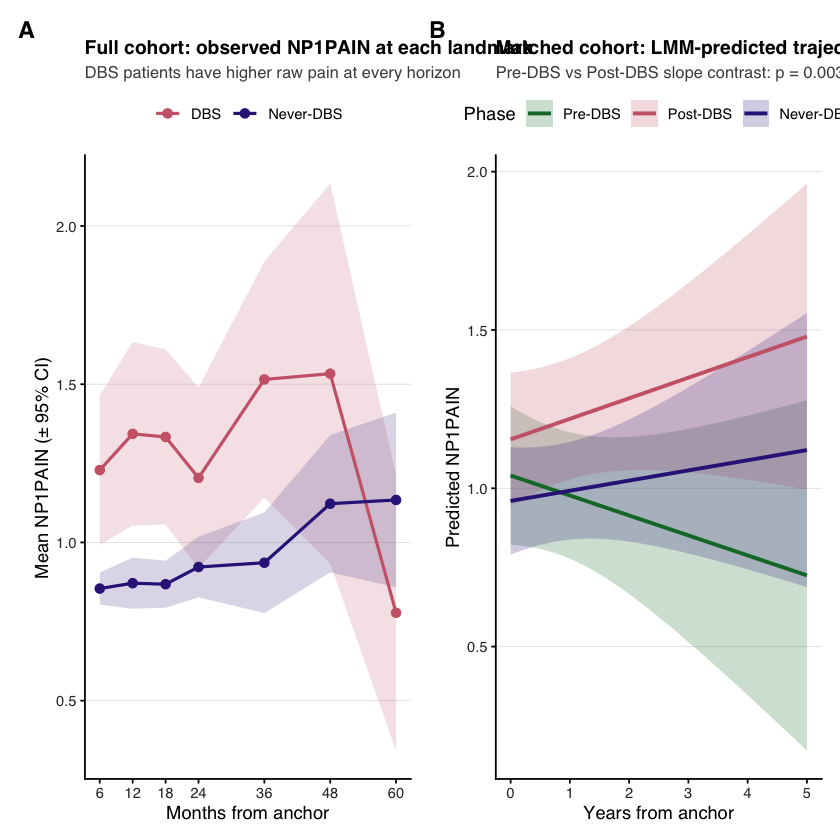

In [3]:
# ---- Figure 2 — Trajectory panel ----
# (A) Observed full-cohort landmark means (F20) | (B) LMM-predicted phase trajectories (F1)
lm_summ <- readr::read_csv(file.path(OUT_TAB, "landmark_summary.csv"), show_col_types = FALSE)

pA <- ggplot(lm_summ, aes(landmark, mean_pain, colour = arm, fill = arm)) +
  geom_ribbon(aes(ymin = lo_pain, ymax = hi_pain), alpha = 0.18, colour = NA) +
  geom_line(linewidth = 0.9) + geom_point(size = 2.3) +
  scale_colour_manual(values = ARM_PAL, name = NULL) +
  scale_fill_manual(values = ARM_PAL, guide = "none") +
  scale_x_continuous(breaks = unique(lm_summ$landmark)) +
  labs(title = "Full cohort: observed NP1PAIN at each landmark",
       subtitle = "DBS patients have higher raw pain at every horizon",
       x = "Months from anchor", y = "Mean NP1PAIN (± 95% CI)", tag = "A") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

# Panel B — re-use LMM predictions from Figure 1 of notebook 99
suppressPackageStartupMessages({ library(lme4); library(emmeans) })
df_long <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
dbs_ids <- df_long %>% dplyr::filter(traj == "Post-DBS") %>% dplyr::pull(PATNO) %>% unique()
excl <- df_long %>% dplyr::filter(traj == "Pre-DBS", PATNO %in% dbs_ids) %>%
  dplyr::group_by(PATNO) %>% dplyr::summarise(mx = max(time_pos_months, na.rm=TRUE), .groups="drop") %>%
  dplyr::filter(mx > 60) %>% dplyr::pull(PATNO)
lmm_data <- df_long %>% dplyr::filter(!PATNO %in% excl) %>%
  dplyr::mutate(time = time_pos_months / 12)
m <- lme4::lmer(NP1PAIN ~ time * traj + (1 + time | PATNO), data = lmm_data,
                weights = weight_sw_trim90, REML = FALSE,
                control = lme4::lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5)))
grid <- expand.grid(time = seq(0, 5, length.out = 200),
                    traj = factor(c("Pre-DBS","Post-DBS","Never-DBS"),
                                  levels = c("Pre-DBS","Post-DBS","Never-DBS")))
pr <- predict(m, newdata = grid, re.form = NA, se.fit = TRUE)
pred <- dplyr::bind_cols(grid, tibble::tibble(fit = pr$fit,
                                              lci = pr$fit - 1.96*pr$se.fit,
                                              uci = pr$fit + 1.96*pr$se.fit))
ct <- as.data.frame(pairs(emmeans::emtrends(m, specs = "traj", var = "time")))
p_prepost <- signif(ct %>% dplyr::filter(grepl("Pre-DBS", contrast), grepl("Post-DBS", contrast)) %>% dplyr::pull(p.value), 3)

pB <- ggplot(pred, aes(time, fit, colour = traj, fill = traj)) +
  geom_ribbon(aes(ymin = lci, ymax = uci), alpha = 0.22, colour = NA) +
  geom_line(linewidth = 1.1) +
  scale_colour_manual(values = TRAJ_PAL, name = "Phase") +
  scale_fill_manual(values = TRAJ_PAL, name = "Phase") +
  labs(title = "Matched cohort: LMM-predicted trajectories by phase",
       subtitle = sprintf("Pre-DBS vs Post-DBS slope contrast: p = %s", p_prepost),
       x = "Years from anchor", y = "Predicted NP1PAIN", tag = "B") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

fig2 <- pA + pB + patchwork::plot_layout(ncol = 2)
fig2
save_pub(fig2, "Figure2_trajectories", w = 12, h = 4.5)

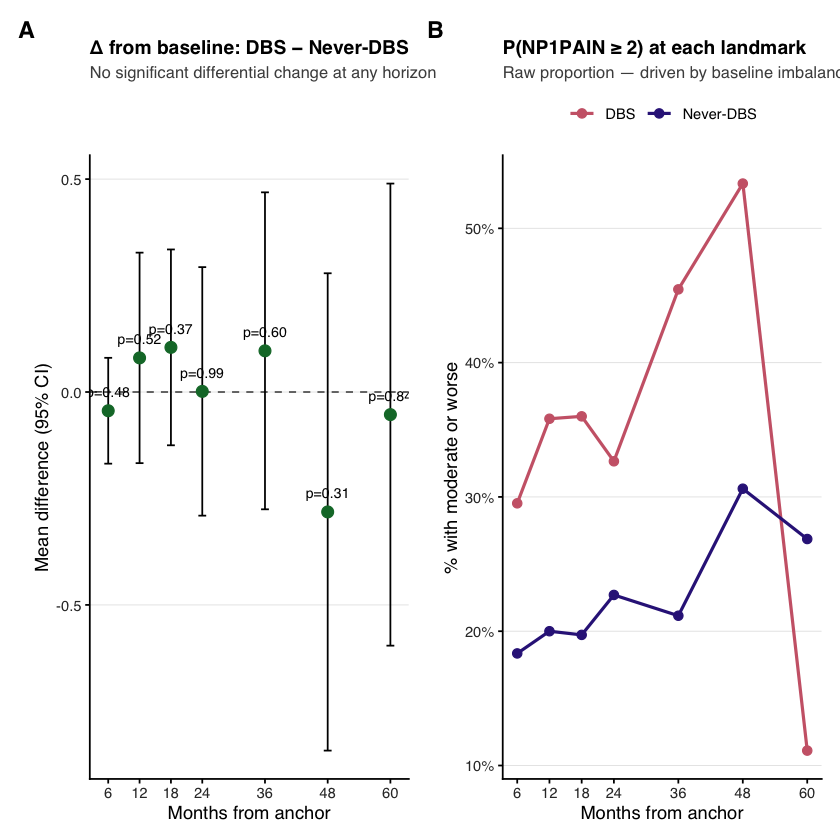

In [4]:
# ---- Figure 3 — Landmark Δ & P(≥2) ----
welch <- readr::read_csv(file.path(OUT_TAB, "landmark_delta_welch.csv"), show_col_types = FALSE) %>%
  dplyr::mutate(signif = ifelse(!is.na(p) & p < 0.05, "*", ""))
lm_summ <- readr::read_csv(file.path(OUT_TAB, "landmark_summary.csv"), show_col_types = FALSE)

pA <- ggplot(welch, aes(landmark, diff)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 1.5, linewidth = 0.5) +
  geom_point(colour = "#117733", size = 3) +
  geom_text(aes(label = sprintf("p=%.2f", p)), vjust = -1.4, size = 3) +
  scale_x_continuous(breaks = welch$landmark) +
  labs(title = "Δ from baseline: DBS − Never-DBS",
       subtitle = "No significant differential change at any horizon",
       x = "Months from anchor", y = "Mean difference (95% CI)", tag = "A") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

pB <- ggplot(lm_summ, aes(landmark, p_moderate, colour = arm, group = arm)) +
  geom_line(linewidth = 0.9) + geom_point(size = 2.3) +
  scale_colour_manual(values = ARM_PAL, name = NULL) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_x_continuous(breaks = unique(lm_summ$landmark)) +
  labs(title = "P(NP1PAIN ≥ 2) at each landmark",
       subtitle = "Raw proportion — driven by baseline imbalance",
       x = "Months from anchor", y = "% with moderate or worse", tag = "B") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

fig3 <- pA + pB + patchwork::plot_layout(ncol = 2)
fig3
save_pub(fig3, "Figure3_landmark", w = 12, h = 4.5)

In [5]:
# ---- Figure 4 — Symptom network (pain highlighted) ----
P_list <- readRDS(file.path(OUT_OBJ, "partial_correlation_matrices.rds"))
P_all  <- P_list$all
png(file.path(OUT_FIG, "Figure4_network.png"), width = 2400, height = 1800, res = 320)
qgraph::qgraph(P_all, layout = "spring", theme = "classic",
               labels = colnames(P_all), label.cex = 1.2, label.scale = FALSE,
               title = "Partial-correlation network of non-motor symptoms",
               color = ifelse(colnames(P_all) == "NP1PAIN", "#CC6677", "#CFE1F2"),
               border.color = "grey20")
invisible(dev.off())
cat("Figure 4 (network) saved.\n")

Figure 4 (network) saved.


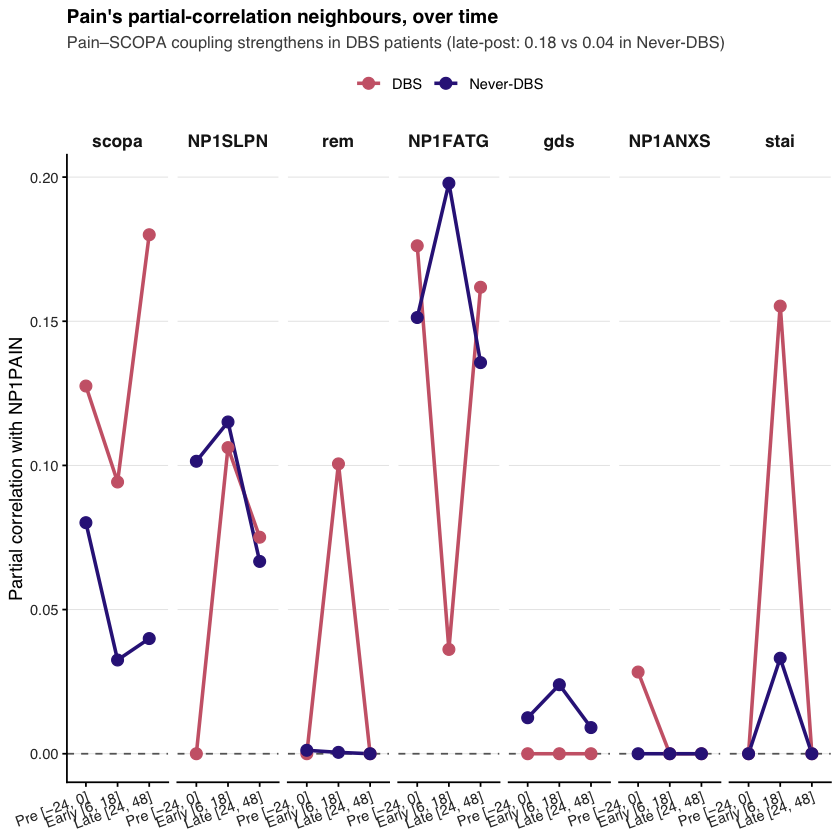

In [6]:
# ---- Figure 5 — Pain-SCOPA coupling over time (F19) ----
long_pcor <- readr::read_csv(file.path(OUT_TAB, "longitudinal_pain_pcor_full.csv"), show_col_types = FALSE)
long_pcor <- long_pcor %>% dplyr::filter(arm != "All") %>%
  dplyr::mutate(window = factor(window, levels = c("pre","early_post","late_post"),
                                labels = c("Pre [−24, 0]", "Early [6, 18]", "Late [24, 48]")),
                partner_f = factor(partner, levels = c("scopa","NP1SLPN","rem","NP1FATG","gds","NP1ANXS","stai")))

fig5 <- ggplot(long_pcor, aes(window, pain_pcor, colour = arm, group = arm)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  facet_wrap(~ partner_f, nrow = 1) +
  scale_colour_manual(values = ARM_PAL, name = NULL) +
  labs(title = "Pain's partial-correlation neighbours, over time",
       subtitle = "Pain–SCOPA coupling strengthens in DBS patients (late-post: 0.18 vs 0.04 in Never-DBS)",
       x = NULL, y = "Partial correlation with NP1PAIN") +
  theme_pub() + theme(axis.text.x = element_text(angle = 20, hjust = 1))
fig5
save_pub(fig5, "Figure5_longitudinal_network", w = 13, h = 4)

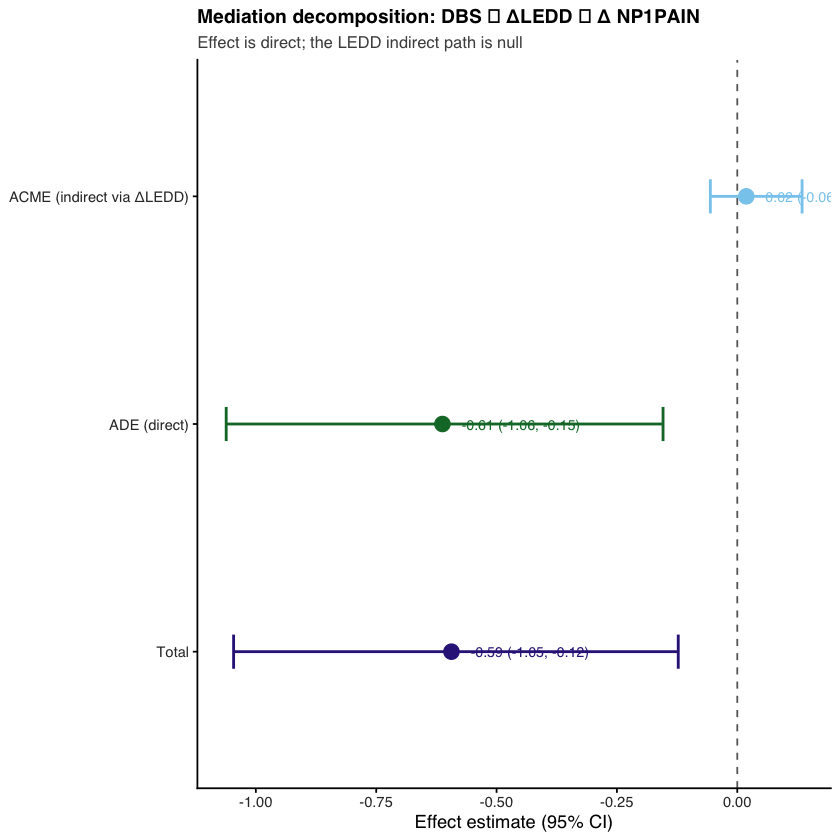

In [7]:
# ---- Figure 6 — Mediation (already good in Figure3_mediation, rebuilt with updated theme) ----
eff <- readr::read_csv(file.path(OUT_TAB, "mediation_effects.csv"), show_col_types = FALSE) %>%
  dplyr::filter(effect != "Prop. mediated") %>%
  dplyr::mutate(effect = forcats::fct_rev(forcats::fct_inorder(effect)))
pal_med <- c("Total" = "#332288", "ADE (direct)" = "#117733", "ACME (indirect via ΔLEDD)" = "#88CCEE")
fig6 <- ggplot(eff, aes(estimate, effect, colour = as.character(effect))) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(xmin = ci_lo, xmax = ci_hi), width = 0.15, orientation = "y", linewidth = 0.8) +
  geom_point(size = 4) +
  geom_text(aes(label = sprintf("%.2f (%.2f, %.2f)", estimate, ci_lo, ci_hi), x = estimate + 0.04),
            size = 3, hjust = 0) +
  scale_colour_manual(values = pal_med, guide = "none") +
  labs(title = "Mediation decomposition: DBS → ΔLEDD → Δ NP1PAIN",
       subtitle = "Effect is direct; the LEDD indirect path is null",
       x = "Effect estimate (95% CI)", y = NULL) +
  theme_pub() + theme(panel.grid.major.y = element_blank())
fig6
save_pub(fig6, "Figure6_mediation", w = 9, h = 3.6)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


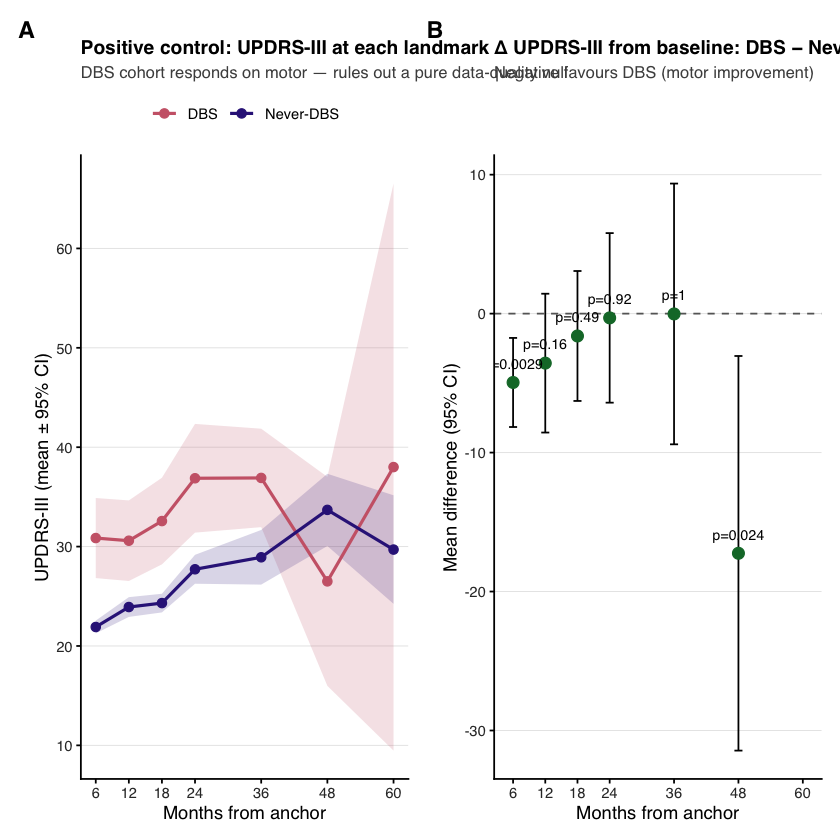

In [8]:
# ---- Figure 7 — Positive control: UPDRS-III ----
u3 <- readr::read_csv(file.path(OUT_TAB, "landmark_updrs3.csv"), show_col_types = FALSE)
u3w <- readr::read_csv(file.path(OUT_TAB, "landmark_updrs3_welch.csv"), show_col_types = FALSE)
pA <- ggplot(u3, aes(landmark, mean_u3, colour = arm, fill = arm)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.18, colour = NA) +
  geom_line(linewidth = 0.9) + geom_point(size = 2.3) +
  scale_colour_manual(values = ARM_PAL, name = NULL) +
  scale_fill_manual(values = ARM_PAL, guide = "none") +
  scale_x_continuous(breaks = unique(u3$landmark)) +
  labs(title = "Positive control: UPDRS-III at each landmark",
       subtitle = "DBS cohort responds on motor — rules out a pure data-quality null",
       x = "Months from anchor", y = "UPDRS-III (mean ± 95% CI)", tag = "A") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

pB <- ggplot(u3w, aes(landmark, diff)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 1.5) +
  geom_point(colour = "#117733", size = 3) +
  geom_text(aes(label = sprintf("p=%.2g", p)), vjust = -1.4, size = 3) +
  scale_x_continuous(breaks = u3w$landmark) +
  labs(title = "Δ UPDRS-III from baseline: DBS − Never-DBS",
       subtitle = "Negative favours DBS (motor improvement)",
       x = "Months from anchor", y = "Mean difference (95% CI)", tag = "B") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

fig7 <- pA + pB + patchwork::plot_layout(ncol = 2)
fig7
save_pub(fig7, "Figure7_positive_control", w = 12, h = 4.5)

Warning message:
“There were 3 warnings in `dplyr::mutate()`.
The first warning was:
ℹ In argument: `x = dplyr::if_else(scale == "ratio", log(est), est)`.
Caused by warning in `log()`:
! NaNs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


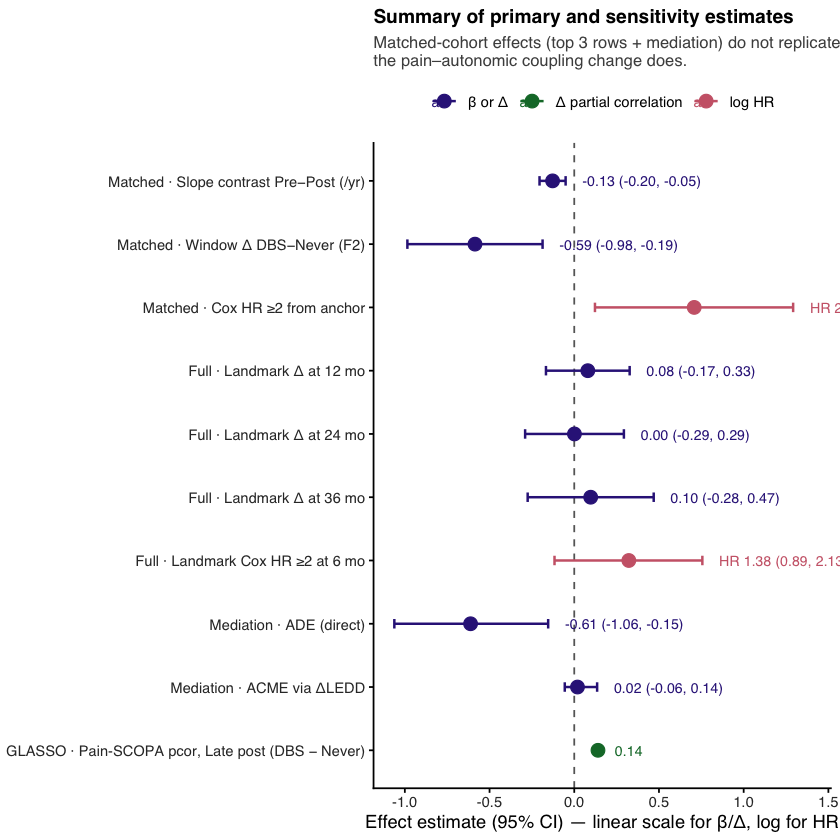

In [9]:
# ---- Figure 8 — Summary forest of main effects (revised) ----
items <- tibble::tribble(
  ~analysis,                                            ~est,    ~lo,    ~hi,   ~scale,  ~cohort,
  "Matched · Slope contrast Pre−Post (/yr)",           -0.128,  -0.205, -0.051, "linear", "Matched",
  "Matched · Window Δ DBS−Never (F2)",                 -0.586,  -0.985, -0.187, "linear", "Matched",
  "Matched · Cox HR ≥2 from anchor",                    2.03,    1.13,   3.64,  "ratio",  "Matched",
  "Full · Landmark Δ at 12 mo",                         0.080,  -0.167,  0.327, "linear", "Full",
  "Full · Landmark Δ at 24 mo",                         0.001,  -0.290,  0.293, "linear", "Full",
  "Full · Landmark Δ at 36 mo",                         0.097,  -0.275,  0.469, "linear", "Full",
  "Full · Landmark Cox HR ≥2 at 6 mo",                  1.38,    0.89,   2.13,  "ratio",  "Full",
  "Mediation · ADE (direct)",                          -0.612,  -1.062, -0.154, "linear", "Matched",
  "Mediation · ACME via ΔLEDD",                         0.019,  -0.056,  0.135, "linear", "Matched",
  "GLASSO · Pain-SCOPA pcor, Late post (DBS − Never)",  0.140,   NA,     NA,    "pcor",   "Full"
)
items <- items %>% dplyr::mutate(
  x  = dplyr::if_else(scale == "ratio", log(est), est),
  xlo = dplyr::if_else(scale == "ratio", log(lo),  lo),
  xhi = dplyr::if_else(scale == "ratio", log(hi),  hi),
  analysis = forcats::fct_rev(forcats::fct_inorder(analysis)),
  label = dplyr::if_else(is.na(lo),
                         sprintf("%.2f", est),
                         dplyr::if_else(scale == "ratio",
                                        sprintf("HR %.2f (%.2f, %.2f)", est, lo, hi),
                                        sprintf("%.2f (%.2f, %.2f)", est, lo, hi)))
)
pal_scale <- c("linear" = "#332288", "ratio" = "#CC6677", "pcor" = "#117733")
fig8 <- ggplot(items, aes(x, analysis, colour = scale)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(xmin = xlo, xmax = xhi), width = 0.15, orientation = "y", linewidth = 0.7, na.rm = TRUE) +
  geom_point(size = 3.5) +
  geom_text(aes(x = ifelse(is.na(xhi), x, xhi) + 0.1, label = label), size = 3, hjust = 0) +
  scale_colour_manual(values = pal_scale,
                      labels = c("linear" = "β or Δ", "ratio" = "log HR", "pcor" = "Δ partial correlation"),
                      name = NULL) +
  coord_cartesian(clip = "off") +
  labs(title = "Summary of primary and sensitivity estimates",
       subtitle = "Matched-cohort effects (top 3 rows + mediation) do not replicate in the full cohort;\nthe pain–autonomic coupling change does.",
       x = "Effect estimate (95% CI) — linear scale for β/Δ, log for HR",
       y = NULL) +
  theme_pub() + theme(panel.grid.major.y = element_blank(), plot.subtitle = element_text(colour = "grey30"))
fig8
save_pub(fig8, "Figure8_summary_forest", w = 12, h = 6)